<a href="https://colab.research.google.com/github/w3aarush/DR_Classification_NIT_MCA_Project/blob/main/EfficientNet_KNN_Multiclass_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [14]:
import tensorflow as tf
# from tensorflow.keras.layers.experimental import preprocessing
from tensorflow import keras
from tensorflow.keras import layers,Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import Attention
# from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve, accuracy_score
import matplotlib.pyplot as plt

In [15]:
from tensorflow.keras.applications.efficientnet_v2 import EfficientNetV2S, preprocess_input
from google.colab.patches import cv2_imshow
import pandas as pd
import numpy as np
import seaborn as sns
# import imutils
import time
import cv2
# from cuml import SVC # for python 3.11
# from sklearn.svm import SVC

In [16]:
# Install Kaggle API
!pip install -q kaggle

# Upload kaggle.json
from google.colab import files
files.upload()

# Setup Kaggle API
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

# Download DATASET (not competition)
!kaggle datasets download -d mariaherrerot/aptos2019

# Unzip
!unzip -q aptos2019.zip -d aptos2019

# Check files
!ls aptos2019

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/mariaherrerot/aptos2019
License(s): unknown
100% 8.01G/8.01G [01:18<00:00, 110MB/s]

test.csv  test_images  train_1.csv  train_images  valid.csv  val_images


In [17]:
base_dir = '/content/aptos2019'
train_dir = '/content/aptos2019/train_images/train_images/'
validation_dir = '/content/aptos2019/val_images/val_images/'
test_dir = '/content/aptos2019/test_images/test_images/'

In [18]:
import os

In [19]:
print(os.listdir(train_dir))
print(os.listdir(validation_dir))
print(os.listdir(test_dir))

['ae975c43bd8b.png', 'ba0107fb1bfd.png', 'cb0cc98d7e35.png', '910bfd38e2f5.png', 'da9262d9f5d9.png', '86baef833ae0.png', '2682e6da9050.png', '42af7282349b.png', 'd4f32b9c07df.png', 'b3c0c3330278.png', 'c67117c6ab3b.png', 'b460ca9fa26f.png', '39fd8ef3a45c.png', '96a9706b8534.png', '65e6f1bd9875.png', 'd1ca85af57c9.png', '6d6fcf49e515.png', '8114d6a160df.png', 'e322acd46152.png', '3ca8be3b40d6.png', '3b232b394e4f.png', '1e9224ccca95.png', 'bf811911acf9.png', 'df6d13d04da1.png', '874f8c1929f6.png', '1ca62b3e4fd3.png', 'cae51154e1ce.png', '76516f828d88.png', '2b07790a2422.png', '7828dd083cdc.png', 'e0b5a982a018.png', '2ef955d6d9ff.png', '929cd3867815.png', '7d37a2939f12.png', '6af071b0ac6e.png', '7a0cff4c24b2.png', 'b5bf7b84fc66.png', '3f5b4c2948e8.png', '4beeca5cc859.png', '4246ed634f25.png', '4ef16a53d899.png', '4c3c1ed09771.png', '94ef1d14597f.png', '8714d17bb6da.png', '72595230840c.png', '7663aba8d762.png', 'cb02bb47fdc5.png', 'b10fca20c885.png', '69df7ade0575.png', '69b3a00927fc.png',

In [20]:
NUM_CLASSES = 5
epochs = 20

In [21]:
BATCH_SIZE = 32

In [ ]:
# img_augmentation = Sequential(
#     [
#         tf.keras.layers.RandomRotation(factor=(-0.15, 0.15)),
#         tf.keras.layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
#         tf.keras.layers.RandomFlip(),
#         tf.keras.layers.RandomContrast(factor=0.1),
#     ],
#     name="img_augmentation",
# )

This code defines an image augmentation pipeline using Keras's Sequential model. It applies a series of random transformations to input images:

RandomRotation(factor=(-0.15, 0.15)): Randomly rotates images by an angle within the range of -15% to +15% of 2π radians.
RandomTranslation(height_factor=0.1, width_factor=0.1): Randomly shifts images horizontally and vertically by up to 10% of their width and height, respectively.
RandomFlip(): Randomly flips images horizontally (left-right).
RandomContrast(factor=0.1): Randomly adjusts the contrast of images by a factor within the range of [1 - 0.1, 1 + 0.1] (i.e., [0.9, 1.1]).
This img_augmentation pipeline is typically used during model training to artificially increase the size and diversity of the training dataset, helping to improve the model's generalization capabilities and reduce overfitting.

In [22]:
def extract_EfficientNetV2S_64_feature_map():
    IMG_SIZE = (224, 224)
    # Load the EfficientNetV2S base model without the top (classification) layer
    base_model = EfficientNetV2S(input_shape=IMG_SIZE + (3,), include_top=False, weights='imagenet')

    # Freeze the base model layers
    base_model.trainable = False

    # Create a new model on top of the base model
    inputs = keras.Input(shape=IMG_SIZE + (3,))
   # x = img_augmentation(inputs)
    x = preprocess_input(inputs) # EfficientNetV2S expects inputs in the [-1, 1] range after preprocessing
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    feature_map = layers.Dense(64, activation='relu')(x)
    # outputs = layers.Dense(5, activation='softmax')(x)
    model = keras.Model(inputs, feature_map)

    # Compile the model
    # model.compile(
    #     optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    #     loss='categorical_crossentropy',
    #     metrics=['accuracy']
    # )
    return model

In [23]:
def effnet_softmax_multiclass():
    # Use the existing feature map logic
    IMG_SIZE = (224, 224)
    base_model = EfficientNetV2S(input_shape=IMG_SIZE + (3,), include_top=False, weights='imagenet')
    base_model.trainable = False

    inputs = keras.Input(shape=IMG_SIZE + (3,))
    x = preprocess_input(inputs)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)

    # The 'feature_map' layer we want to optimize
    feature_layer = layers.Dense(64, activation='relu', name='feature_extraction_layer')(x)

    # The 'classification_head' needed to calculate the cost function (Loss)
    # This is what allows model.fit() to actually update the weights
    outputs = layers.Dense(5, activation='softmax')(feature_layer)

    model = keras.Model(inputs, outputs)
    return model

In [24]:
def unfreeze_model(model):
    # unfreeze the top 10 layers while leaving BatchNorm layers frozen for fine-tuning
    for layer in model.layers[-10:]:
        if not isinstance(layer, layers.BatchNormalization):
            print("executed")
            layer.trainable = True
    # optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
    # model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

In [25]:
def test_model(model, test_batches):
    test_labels = test_batches.classes
    print("Test Lables", test_labels)
    print(test_batches.class_indices)

    # predictions = model.predict(test_batches, step=len(test_batches), verbose=0)
    predictions = model.predict(test_batches, verbose=0)


    acc = 0
    for i in range(len(test_labels)):
        actual_class = test_labels[i]
        if predictions[i][actual_class] > 0.5:
            acc += 1
    print('Accuracy:', (acc/len(test_labels))*100, "% ")
    # Convert predictions to discrete class labels for classification_report
    predicted_labels = np.argmax(predictions, axis=1)
    print('Classification Report:', classification_report(test_batches.labels, predicted_labels))

In [26]:
def load_data():
    train = pd.read_csv('/content/aptos2019/train_1.csv', encoding='utf-8')
    test = pd.read_csv('/content/aptos2019/test.csv', encoding='utf-8')
    valid = pd.read_csv('/content/aptos2019/valid.csv')

    train_dir = '/content/aptos2019/train_images/train_images/'
    test_dir = '/content/aptos2019/test_images/test_images/'
    valid_dir = '/content/aptos2019/val_images/val_images/'

    # construct file paths directly within function:
    train['image_path'] = train_dir + train['id_code'] + '.png'
    test['image_path'] = test_dir + test['id_code'] + '.png'
    valid['image_path'] = valid_dir + valid['id_code'] + '.png'

    train['train_images'] = train['id_code'] + '.png'
    test['test_images'] = test['id_code'] + '.png'
    valid['valid_images'] = valid['id_code'] + '.png'

    train['diagnosis'] = train['diagnosis'].astype(str)
    # train['target'] = [1 if x >= 1 else 0 for x in train['diagnosis']]
    # train['target'] = train['target'].astype(str)
    test['diagnosis'] = test['diagnosis'].astype(str)
    # test['target'] = [1 if x >= 1 else 0 for x in test['diagnosis']]
    # test['target'] = test['target'].astype(str)
    valid['diagnosis'] = valid['diagnosis'].astype(str)
    # valid['target'] = [1 if x >= 1 else 0 for x in valid['diagnosis']]
    # valid['target'] = valid['target'].astype(str)

    return train, test, valid

In [27]:
def preprocess_image(image_path):
    img = load_img(image_path, target_size=(224, 224))
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis = 0)
    return preprocess_input(img_array)

In [28]:
train_df, test_df, valid_df = load_data()

In [29]:
# Initialize all data generators in the global scope
train_batches = ImageDataGenerator(preprocessing_function=tf.keras.applications.efficientnet_v2.preprocess_input).flow_from_dataframe(
    dataframe=train_df, x_col='image_path', y_col='diagnosis', target_size=(224,224), batch_size=BATCH_SIZE)

valid_batches = ImageDataGenerator(preprocessing_function=tf.keras.applications.efficientnet_v2.preprocess_input).flow_from_dataframe(
    dataframe=valid_df, x_col='image_path', y_col='diagnosis', target_size=(224,224), batch_size=BATCH_SIZE)

test_batches = ImageDataGenerator(preprocessing_function=tf.keras.applications.efficientnet_v2.preprocess_input).flow_from_dataframe(
    dataframe=test_df, x_col='image_path', y_col='diagnosis', target_size=(224,224), batch_size=BATCH_SIZE, shuffle=False)

Found 2930 validated image filenames belonging to 5 classes.
Found 366 validated image filenames belonging to 5 classes.
Found 366 validated image filenames belonging to 5 classes.


In [ ]:
# Instantiate the model with the classification head
train_model = effnet_softmax_multiclass()

# Compile the model
train_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-4)

# Start training
history = train_model.fit(
    train_batches,
    epochs=epochs,
    validation_data=valid_batches,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# Save the model after initial training
# train_model.save('effnet_softmax_multiclass_64perceptron.h5')
train_model.save('/content/drive/MyDrive/effnet_softmax_multiclass_64perceptron.keras')
print('Model saved after initial training as initial_trained_model.h5')

Epoch 1/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 493s 5s/step - accuracy: 0.7215 - loss: 0.7739 - val_accuracy: 0.7541 - val_loss: 0.6282 - learning_rate: 0.0010
Epoch 2/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 395s 4s/step - accuracy: 0.7662 - loss: 0.6193 - val_accuracy: 0.7541 - val_loss: 0.6302 - learning_rate: 0.0010
Epoch 3/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 397s 4s/step - accuracy: 0.7765 - loss: 0.5730 - val_accuracy: 0.7596 - val_loss: 0.6242 - learning_rate: 0.0010
Epoch 4/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 393s 4s/step - accuracy: 0.8020 - loss: 0.5491 - val_accuracy: 0.7842 - val_loss: 0.5914 - learning_rate: 0.0010
Epoch 5/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 398s 4s/step - accuracy: 0.8017 - loss: 0.5203 - val_accuracy: 0.7951 - val_loss: 0.5603 - learning_rate: 0.0010
Epoch 6/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 390s 4s/step - accuracy: 0.8126 - loss: 0.4997 - val_accuracy: 0.7978 - val_loss: 0.5562 - learning_rate: 0.0010
Epoch 7/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 397s 4s/step - accuracy: 0.8205 - loss: 0.4964 - val_acc

After the initial training with a frozen base, we will now unfreeze the top layers of the base model for fine-tuning. This process typically involves recompiling the model with a lower learning rate and then training it for additional epochs to allow the pre-trained layers to adapt to your specific dataset.

In [ ]:
print('Unfreezing top layers for fine-tuning...')
unfreeze_model(train_model)

# Recompile the model with a much smaller learning rate for fine-tuning
train_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), # A smaller learning rate is crucial for fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('Continuing training with unfrozen layers for fine-tuning...')
# Continue training for a few more epochs with the unfrozen layers
history_fine_tune = train_model.fit(
    train_batches,
    epochs=epochs, # You can adjust epochs if you want more fine-tuning steps
    validation_data=valid_batches,
    callbacks=[early_stopping, reduce_lr], # Continue using the same callbacks
    verbose=1
)

# Save the model after fine-tuning
# train_model.save('fine_tuned_model_effnet_softmax_multiclass.h5')
train_model.save('/content/drive/MyDrive/fine_tuned_model_effnet_softmax_multiclass.keras')
print('Model saved after fine-tuning as fine_tuned_model.h5')

Unfreezing top layers for fine-tuning...
executed
executed
executed
executed
executed
Continuing training with unfrozen layers for fine-tuning...
Epoch 1/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 694s 6s/step - accuracy: 0.6133 - loss: 0.9845 - val_accuracy: 0.6885 - val_loss: 0.7694 - learning_rate: 1.0000e-05
Epoch 2/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 403s 4s/step - accuracy: 0.7345 - loss: 0.7199 - val_accuracy: 0.7268 - val_loss: 0.6753 - learning_rate: 1.0000e-05
Epoch 3/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 398s 4s/step - accuracy: 0.7679 - loss: 0.6233 - val_accuracy: 0.7568 - val_loss: 0.6175 - learning_rate: 1.0000e-05
Model saved after fine-tuning as fine_tuned_model.h5


## Loading Trained Model
<p>Model was saved to google drive after being trained.</p>

In [30]:
# loading fine-tuned model
finetune_model = tf.keras.models.load_model('/content/drive/MyDrive/ML Projects/trained_models/effnet_KNN/fine_tuned_model_effnet_softmax_multiclass_64perceptron.keras')

In [31]:
finetune_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-s (Functional)   │ (None, 7, 7, 1280)     │    20,331,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_extraction_layer        │ (None, 64)             │        81,984 │
│ (Dense)                         │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 60,933,265 (232.44 MB)

 Trainable params: 20,259,797 (77.28 MB)

 Non-trainable params: 153,872 (601.06 KB)

 Optimizer params: 40,519,596 (154.57 MB)

# Preparing DataFrame

Now that the model has been fine-tuned, we can extract the 64-dimensional feature vectors from the `feature_extraction_layer`. We will create a new Keras model specifically for this purpose, using the `train_model`'s input and outputting the activations of the named feature layer.

In [22]:
from tqdm import tqdm

In [24]:
# Create a new model that takes the same input as train_model and outputs the 'feature_extraction_layer'
feature_extractor = keras.Model(
    inputs=finetune_model.inputs,
    outputs=finetune_model.get_layer('feature_extraction_layer').output
)

# Extract features for the training dataset
X_train_features = feature_extractor.predict(train_batches)
y_train_labels = train_batches.classes

# Extract features for the test dataset
X_test_features = feature_extractor.predict(test_batches)
y_test_labels = test_batches.classes

92/92 ━━━━━━━━━━━━━━━━━━━━ 768s 8s/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 92s 7s/step
Shape of extracted training features: (2930, 64)


AttributeError: 'list' object has no attribute 'shape'

In [27]:
print('Shape of extracted training features:', X_train_features.shape)
# print('Shape of extracted training labels:', y_train_labels.shape)
print('Shape of extracted test features:', X_test_features.shape)
# print('Shape of extracted test labels:', y_test_labels.shape)

print('\nThese extracted features (X_train_features, X_test_features) can now be used to train and evaluate your KNN model.')

Shape of extracted training features: (2930, 64)
Shape of extracted test features: (366, 64)

These extracted features (X_train_features, X_test_features) can now be used to train and evaluate your KNN model.


# KNN

Finally, we will use the extracted 64-dimensional features to train a K-Nearest Neighbors (KNN) classifier and evaluate its performance. This demonstrates how the learned features can be used with traditional machine learning models.

## Visualizing Feature Space with t-SNE
To understand why the KNN model performed as it did, let's visualize the 64-dimensional feature vectors in a 2D space using t-SNE (t-distributed Stochastic Neighbor Embedding). This will help us see if the extracted features form distinct clusters for each class.

Shape of combined features: (3296, 64)
Shape of combined labels: (3296,)
Applying t-SNE...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE completed.


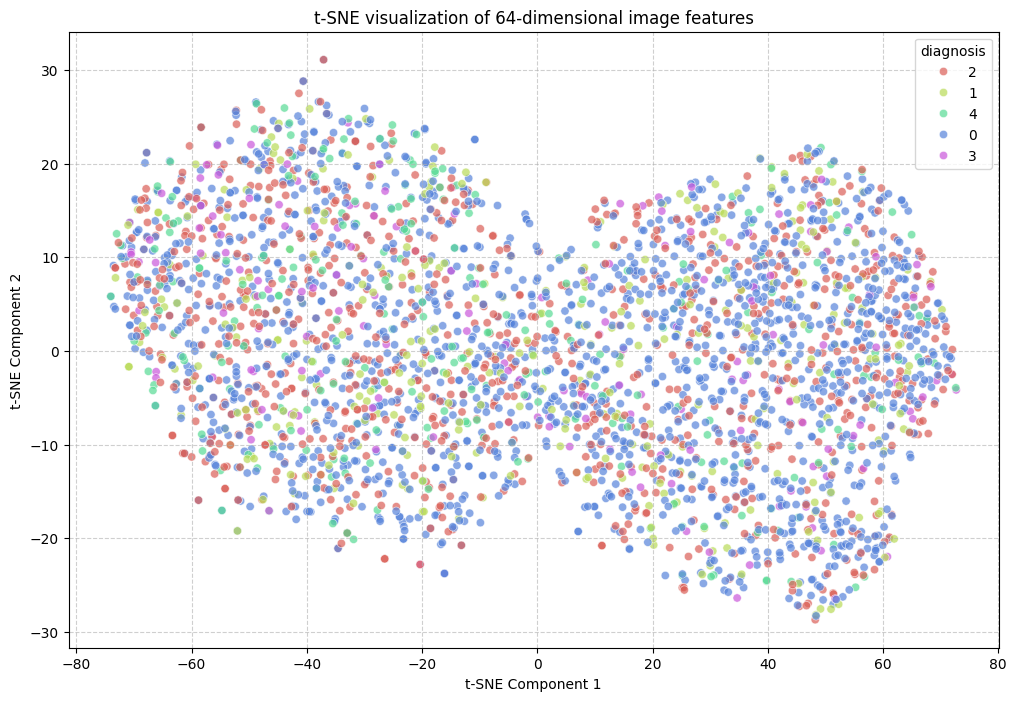

In [29]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Combine training and test features and labels
all_features = np.vstack((X_train_features, X_test_features))
all_labels = np.hstack((y_train_labels, y_test_labels))

print(f"Shape of combined features: {all_features.shape}")
print(f"Shape of combined labels: {all_labels.shape}")

# Apply t-SNE for dimensionality reduction
# It's good practice to try different perplexity values and iterations
# For initial exploration, default values are often a good start.
# Increased n_iter and set random_state for reproducibility.
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
print("Applying t-SNE...")
tsne_results = tsne.fit_transform(all_features)
print("t-SNE completed.")

# Create a DataFrame for plotting
df_tsne = pd.DataFrame(data=tsne_results, columns=['tsne-2d-one', 'tsne-2d-two'])
df_tsne['diagnosis'] = all_labels.astype(str)

# Plot the t-SNE results
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x="tsne-2d-one", y="tsne-2d-two",
    hue="diagnosis",
    palette=sns.color_palette("hls", len(np.unique(all_labels))),
    data=df_tsne,
    legend="full",
    alpha=0.7
)
plt.title('t-SNE visualization of 64-dimensional image features')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [28]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# Instantiate KNN classifier with a chosen number of neighbors (e.g., 20)
knn = KNeighborsClassifier(n_neighbors=20)

# Train the KNN model using the extracted training features and labels
print('Training KNN classifier...')
knn.fit(X_train_features, y_train_labels)
print('KNN classifier trained.')

# Make predictions on the extracted test features
print('Making predictions with KNN...')
y_pred = knn.predict(X_test_features)

# Evaluate the KNN model's performance
accuracy = accuracy_score(y_test_labels, y_pred)
print(f'\nKNN Accuracy on extracted features: {accuracy:.4f}')

# Print a detailed classification report
print('\nClassification Report for KNN:')
print(classification_report(y_test_labels, y_pred))

Training KNN classifier...
KNN classifier trained.
Making predictions with KNN...

KNN Accuracy on extracted features: 0.5000

Classification Report for KNN:
              precision    recall  f1-score   support

           0       0.54      0.88      0.67       199
           1       0.00      0.00      0.00        30
           2       0.19      0.08      0.11        87
           3       0.00      0.00      0.00        17
           4       0.00      0.00      0.00        33

    accuracy                           0.50       366
   macro avg       0.15      0.19      0.16       366
weighted avg       0.34      0.50      0.39       366



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Retraining Model with Class Weights
To address the class imbalance observed in the t-SNE visualization and classification report, we will calculate class weights and incorporate them into the model training. This will help the model pay more attention to underrepresented classes.

In [32]:
from sklearn.utils import class_weight

# Calculate class weights
# train_batches.classes contains the integer labels for each sample
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_batches.classes),
    y=train_batches.classes
)

# Convert to a dictionary mapping class index to weight
class_weights_dict = dict(enumerate(class_weights))

print("Calculated Class Weights:", class_weights_dict)

Calculated Class Weights: {0: np.float64(0.4086471408647141), 1: np.float64(1.9533333333333334), 2: np.float64(0.7252475247524752), 3: np.float64(3.8051948051948052), 4: np.float64(2.5042735042735043)}


In [33]:
dict(enumerate(class_weights))

{0: np.float64(0.4086471408647141),
 1: np.float64(1.9533333333333334),
 2: np.float64(0.7252475247524752),
 3: np.float64(3.8051948051948052),
 4: np.float64(2.5042735042735043)}

In [40]:
# This cell previously contained markdown text and caused a SyntaxError when run as code.
# Please ensure this is a Text cell if you intend for it to contain explanations.
# For now, its content has been commented out to prevent execution errors.

After the initial training with class weights, we will now unfreeze the top layers for fine-tuning, also using the calculated class weights. This aims to further improve the model's ability to handle class imbalance.

In [34]:
def unfreeze_model(model):
    # unfreeze the top 10 layers while leaving BatchNorm layers frozen for fine-tuning
    for layer in model.layers[-10:]:
        if not isinstance(layer, layers.BatchNormalization):
            print("executed")
            layer.trainable = True

# Define callbacks again to ensure they are in scope within this cell
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-4)

print('Unfreezing top layers for fine-tuning with class weights...')
unfreeze_model(finetune_model) # Use the loaded finetune_model

# Recompile the model with a much smaller learning rate for fine-tuning
finetune_model.compile( # Use the loaded finetune_model
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), # A smaller learning rate is crucial for fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('Continuing training with unfrozen layers and class weights for fine-tuning...')
# Continue training for a few more epochs with the unfrozen layers and class weights
history_fine_tune_weighted = finetune_model.fit( # Use the loaded finetune_model
    train_batches,
    epochs=epochs, # You can adjust epochs if you want more fine-tuning steps
    validation_data=valid_batches,
    callbacks=[early_stopping, reduce_lr],
    class_weight=class_weights_dict, # Apply class weights here as well
    verbose=1
)

# Save the model after fine-tuning with class weights
finetune_model.save('/content/drive/MyDrive/fine_tuned_model_effnet_softmax_multiclass_weighted.keras')
print('Model saved after fine-tuning with class weights.')

Unfreezing top layers for fine-tuning with class weights...
executed
executed
executed
executed
executed
Continuing training with unfrozen layers and class weights for fine-tuning...
Epoch 1/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.7151 - loss: 1.0993

KeyboardInterrupt: 